In [1]:
from langchain.document_loaders import PyPDFLoader, DirectoryLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

c:\Users\shyam\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#extract text from pdf file
def load_pdf_files(data):
    loader = DirectoryLoader(data, glob="*.pdf", loader_cls= PyPDFLoader)
    
    documents = loader.load()
    return documents


In [11]:
extracted_data = load_pdf_files("D:/New Project/Ai-Ml/MedicalChatbot--main/Data")

In [12]:
extracted_data
len(extracted_data)

637

In [13]:
#filter operation
from typing import List
from langchain.schema import Document

def filter_to_minimal_documents(documents: List[Document]) -> List[Document]:
    #containing only source in metadata and page content 
    minimal_documents = []
    for doc in documents:
        minimal_doc = Document(
            page_content=doc.page_content,
            metadata={
                "source": doc.metadata.get("source", "")
            }
        )
        minimal_documents.append(minimal_doc)
    return minimal_documents
minimal_docs = filter_to_minimal_documents(extracted_data)
minimal_docs[1]

Document(metadata={'source': 'D:\\New Project\\Ai-Ml\\MedicalChatbot--main\\Data\\Medical_book.pdf'}, page_content='The GALE\nENCYCLOPEDIA\nof MEDICINE\nSECOND EDITION')

In [14]:
#chunking the data
def text_split(minimal_docs):
    text_splitter = RecursiveCharacterTextSplitter(chunk_size= 1000, chunk_overlap=200)
    text = text_splitter.split_documents(minimal_docs)
    return text

chunked_data = text_split(minimal_docs)
print(f"Number of chunks: {len(chunked_data)}")

Number of chunks: 3426


In [15]:
#embedding model
from langchain.embeddings import HuggingFaceBgeEmbeddings


def download_embeddings():
    # downlload and return the embedding model
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
    embedding = HuggingFaceBgeEmbeddings(model_name=model_name)
    return embedding

embedding = download_embeddings()

C:\Users\shyam\AppData\Local\Temp\ipykernel_24728\3284288926.py:8: LangChainDeprecationWarning: The class `HuggingFaceBgeEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding = HuggingFaceBgeEmbeddings(model_name=model_name)
c:\Users\shyam\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shyam\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by settin

In [16]:
embedding

HuggingFaceBgeEmbeddings(client=SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
), model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_instruction='Represent this question for searching relevant passages: ', embed_instruction='', show_progress=False)

c:\Users\shyam\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


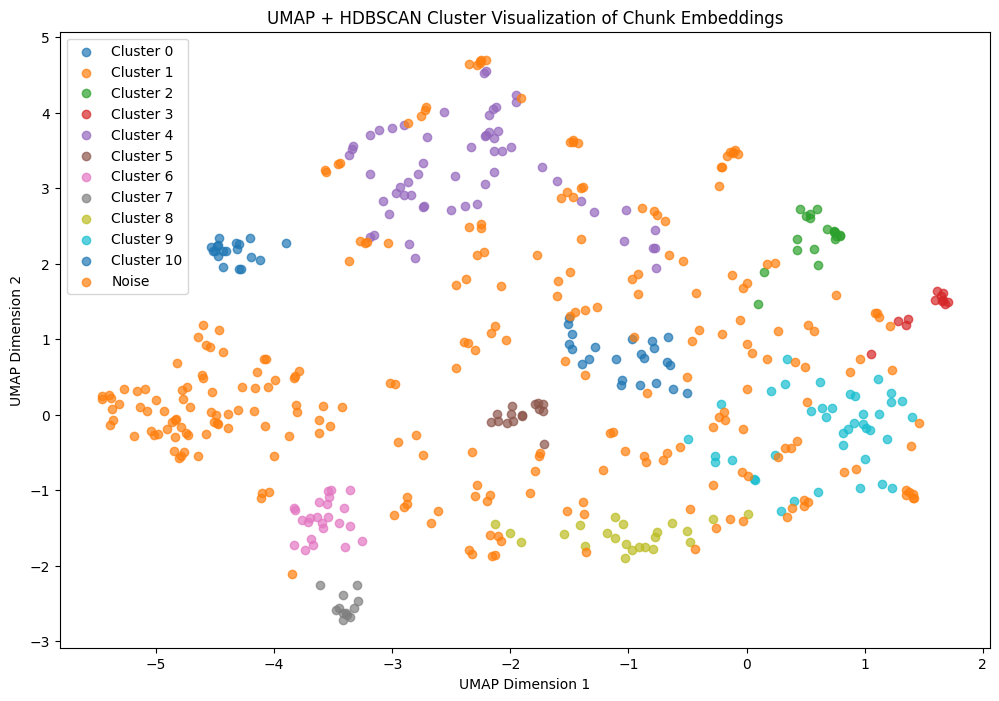

In [18]:
import random
import numpy as np
import matplotlib.pyplot as plt
import umap
import hdbscan

# Random sample so we don't only get early pages
sample_size = 500
sample_docs = random.sample(chunked_data, sample_size)

texts = [doc.page_content for doc in sample_docs]

# Create embeddings
vectors = np.array(embedding.embed_documents(texts))

# UMAP dimensionality reduction
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

reduced_vectors = reducer.fit_transform(vectors)

# HDBSCAN automatic clustering
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10
)

clusters = clusterer.fit_predict(reduced_vectors)

# Plot clusters
plt.figure(figsize=(12,8))

unique_clusters = set(clusters)

for cluster_id in unique_clusters:
    idx = clusters == cluster_id
    
    if cluster_id == -1:
        label = "Noise"
    else:
        label = f"Cluster {cluster_id}"
    
    plt.scatter(
        reduced_vectors[idx,0],
        reduced_vectors[idx,1],
        label=label,
        alpha=0.7
    )

plt.title("UMAP + HDBSCAN Cluster Visualization of Chunk Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.show()

In [19]:
vector = embedding.embed_query("hello world")
print(vector)
print(f"Vector length: {len(vector)}")

[-0.010300842113792896, 0.18307924270629883, 0.030811164528131485, 0.004452849272638559, -0.0273361224681139, -0.033562541007995605, 0.03763149306178093, -0.0315733440220356, -0.0033910549245774746, -0.008950856514275074, 0.038036126643419266, -0.05129105597734451, 0.00036828979500569403, -0.02372710593044758, 0.09271020442247391, -0.02779579348862171, -0.03515255078673363, -0.003224167739972472, -0.07681781053543091, -0.057612158358097076, 0.07257603108882904, 0.1112854853272438, 0.016058506444096565, 0.01590847596526146, -0.08232703059911728, 0.007007299456745386, 0.029013091698288918, 0.0011386318365111947, 0.1167173683643341, -0.032327309250831604, -0.03227159380912781, -0.001259051845408976, 0.10591623932123184, 0.023600822314620018, 0.009664932265877724, 0.09834080934524536, 0.0429362878203392, -0.0195475984364748, 0.019267886877059937, -0.06417102366685867, 0.02392333559691906, -0.05288001894950867, -0.02646954171359539, 0.005548684857785702, -0.017025213688611984, -0.0302327051

In [20]:
from dotenv import load_dotenv
load_dotenv()

True

In [21]:
import os 
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
#set the environment variables for Pinecone and OpenAI API keys
os.environ["PINECONE_API_KEY"] = PINECONE_API_KEY
os.environ["OPENROUTER_API_KEY"] = OPENROUTER_API_KEY

In [22]:
from pinecone import Pinecone
pinconeapikey = PINECONE_API_KEY
pc = Pinecone(api_key=pinconeapikey)

In [23]:
pc

In [25]:
#creating databse
from pinecone import ServerlessSpec
index_name = "medicalchabot"
if not pc.has_index(index_name):
    pc.create_index(
                name=index_name,  
                dimension=384, #embedding vector length
                metric="cosine", #similarity metric
                spec =ServerlessSpec(cloud="aws", region="us-east-1")
           )
    
index = pc.Index(index_name)
    


In [26]:
#load exisiting index 
from langchain_pinecone import PineconeVectorStore


index_name = "medicalchabot"
docserach = PineconeVectorStore.from_existing_index(
    index_name=index_name,
    embedding=embedding,  
)  

In [27]:
from langchain_core.documents import Document

clean_docs = []
for d in chunked_data:
    md = dict(d.metadata or {})
    # Remove keys with None values
    md = {k: v for k, v in md.items() if v is not None}

    # Optional: ensure page_number is always an int if present
    if "page_number" in md and md["page_number"] is not None:
        md["page_number"] = int(md["page_number"])

    clean_docs.append(Document(page_content=d.page_content, metadata=md))

In [28]:
from langchain_pinecone import PineconeVectorStore
docserach = PineconeVectorStore.from_documents(
    documents = chunked_data, 
    embedding=embedding, 
    index_name=index_name
    )


In [29]:
retriever = docserach.as_retriever(search_type="mmr",search_kwargs={"k": 6})

from sentence_transformers import CrossEncoder

reranker = CrossEncoder("BAAI/bge-reranker-base")

def rerank_documents(query, docs, top_k=3):

    pairs = [[query, doc.page_content] for doc in docs]

    scores = reranker.predict(pairs)

    scored_docs = list(zip(docs, scores))

    ranked_docs = sorted(scored_docs, key=lambda x: x[1], reverse=True)

    return [doc for doc, score in ranked_docs[:top_k]]

c:\Users\shyam\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shyam\.cache\huggingface\hub\models--BAAI--bge-reranker-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling ba

In [30]:
from langchain_openai import ChatOpenAI

chatModel = ChatOpenAI(
    model="meta-llama/llama-3-8b-instruct",
    temperature=0,
    openai_api_key=os.getenv("OPENROUTER_API_KEY"),
    openai_api_base="https://openrouter.ai/api/v1",
)


In [31]:
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate


In [33]:
system_prompt = """
You are a helpful medical-information assistant, not a doctor.
Answer only from the retrieved context.
If the context is insufficient, say: "I don't have enough information in the retrieved documents to answer safely."
Do not invent treatments, diagnoses, or emergency instructions.
Keep the answer concise and include the source page if available.

Context:
{context}
"""
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("human", "{input}")
    ]
)


question_answering_chain = create_stuff_documents_chain(chatModel, prompt)
rag_chain = create_retrieval_chain(retriever, question_answering_chain)

In [34]:

query = "What is acne?"

docs = retriever.invoke(query)

reranked_docs = rerank_documents(query, docs, top_k=3)

response = question_answering_chain.invoke({
    "input": query,
    "context": reranked_docs
})

print(response)

Acne is a common skin disease characterized by pimples on the face, chest, and back, caused by clogged pores with oil, dead skin cells, and bacteria.


In [35]:
import time
query = "What is ADHD?"   # Botulism Audiometry
start = time.time()

docs = retriever.invoke(query)
retrieval_time = time.time() - start

reranked_docs = rerank_documents(query, docs, top_k=3)
rerank_time = time.time() - start - retrieval_time

response = question_answering_chain.invoke({
    "input": query,
    "context": reranked_docs
})

total_time = time.time() - start
print(response)
print("retrieval:", retrieval_time)
print("rerank:", rerank_time)
print("total:", total_time)


Attention-deficit/hyperactivity disorder (ADHD) is a developmental disorder characterized by distractibility, hyperactivity, impulsive behaviors, and the inability to remain focused on tasks or activities.
retrieval: 0.3412292003631592
rerank: 1.5870575904846191
total: 2.9518468379974365
